By [Kevin Michalewicz](https://kevinmichalewicz.com) and [Martin Millon](https://martin-millon.gitlab.io/) on July 2023

This notebook shows how to deconvolve a JWST galaxy image for the F200W band. Before that, the narrow PSF is obtained. It is important to notice that the noise maps are given in this case.

In [4]:
import glob
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import os
import pyregion 

from copy import deepcopy
from matplotlib import colors

from starred.deconvolution.deconvolution import Deconv, setup_model
from starred.deconvolution.loss import Loss as decLoss
from starred.deconvolution.parameters import ParametersDeconv
from starred.utils.noise_utils import propagate_noise
from starred.optim.optimization import Optimizer

from starred.plots import plot_function as pltf

from starred.psf.psf import PSF
from starred.psf.loss import Loss
from starred.psf.parameters import ParametersPSF

from starred.utils import ds9reg
from starred.utils.noise_utils import propagate_noise
from starred.procedures.psf_routines import run_multi_steps_PSF_reconstruction

# yourdevice = jax.default_backend()
# if yourdevice != "gpu":
#     jax.config.update("jax_enable_x64", True)

#print(f"You are running on {yourdevice}.")

# STEP 1 : PSF reconstruction

We will reconstruct the PSF, using the high-level function `run_2_steps_PSF_reconstruction` from the `starred.utils.fitting_sequence` module. It will first build an analytical model from a Moffat function and then refine it with regularized pixel grid.

In [5]:
# Parameters
subsampling_factor = 2 #this can be increased fo a better resolution, try 3 or 4 ! 
n_iter_initial = 50
n_iter = 2000 

lambda_scales = 2.0
lambda_hf = 2.0
lambda_positivity = 0. #penalising term if the full psf have negative pixels. Leave it to 0. in most cases to save computationnal time.
include_moffat = True

method1 = 'l-bfgs-b'
method2 = 'adabelief'
data_path = 'data/4_observations'
noise_map_path = 'data/4_obs_noise_maps'
convolution_method = 'fft'

In [6]:
# Data 
file_paths_data = sorted(glob.glob(os.path.join(data_path, 'jwst_f200w_*.npy')))
new_vignets_data = np.array([np.load(f) for f in file_paths_data]) 
N = len(file_paths_data) # number of stars
image_size = np.shape(new_vignets_data)[1] # data dimensions
image_size_up = image_size * subsampling_factor 

In [7]:
# Masking
masks = np.ones((N, image_size, image_size))
for i in range(N):
    possiblemaskfilepath = os.path.join(noise_map_path, 'mask_%s.reg'%str(i))
    if os.path.exists(possiblemaskfilepath):
        print(f'I found a mask for star {i}.')
        r = pyregion.open(possiblemaskfilepath)
        masks[i, :, :] =  1 - r.get_mask(shape=(image_size, image_size)).astype(float)

In [8]:
# Noise map obtention
sigma_paths = sorted(glob.glob(os.path.join(noise_map_path, 'jwst_f200w_*.npy')))
sigma_2 = np.array([np.load(f) for f in sigma_paths]) ** 2

#Renormalise your data and the noise maps by the max of the first image. Works better when using adabelief
norm = new_vignets_data[0].max() / 100.
new_vignets_data /= norm
sigma_2 /= norm**2

(3, 32, 32)


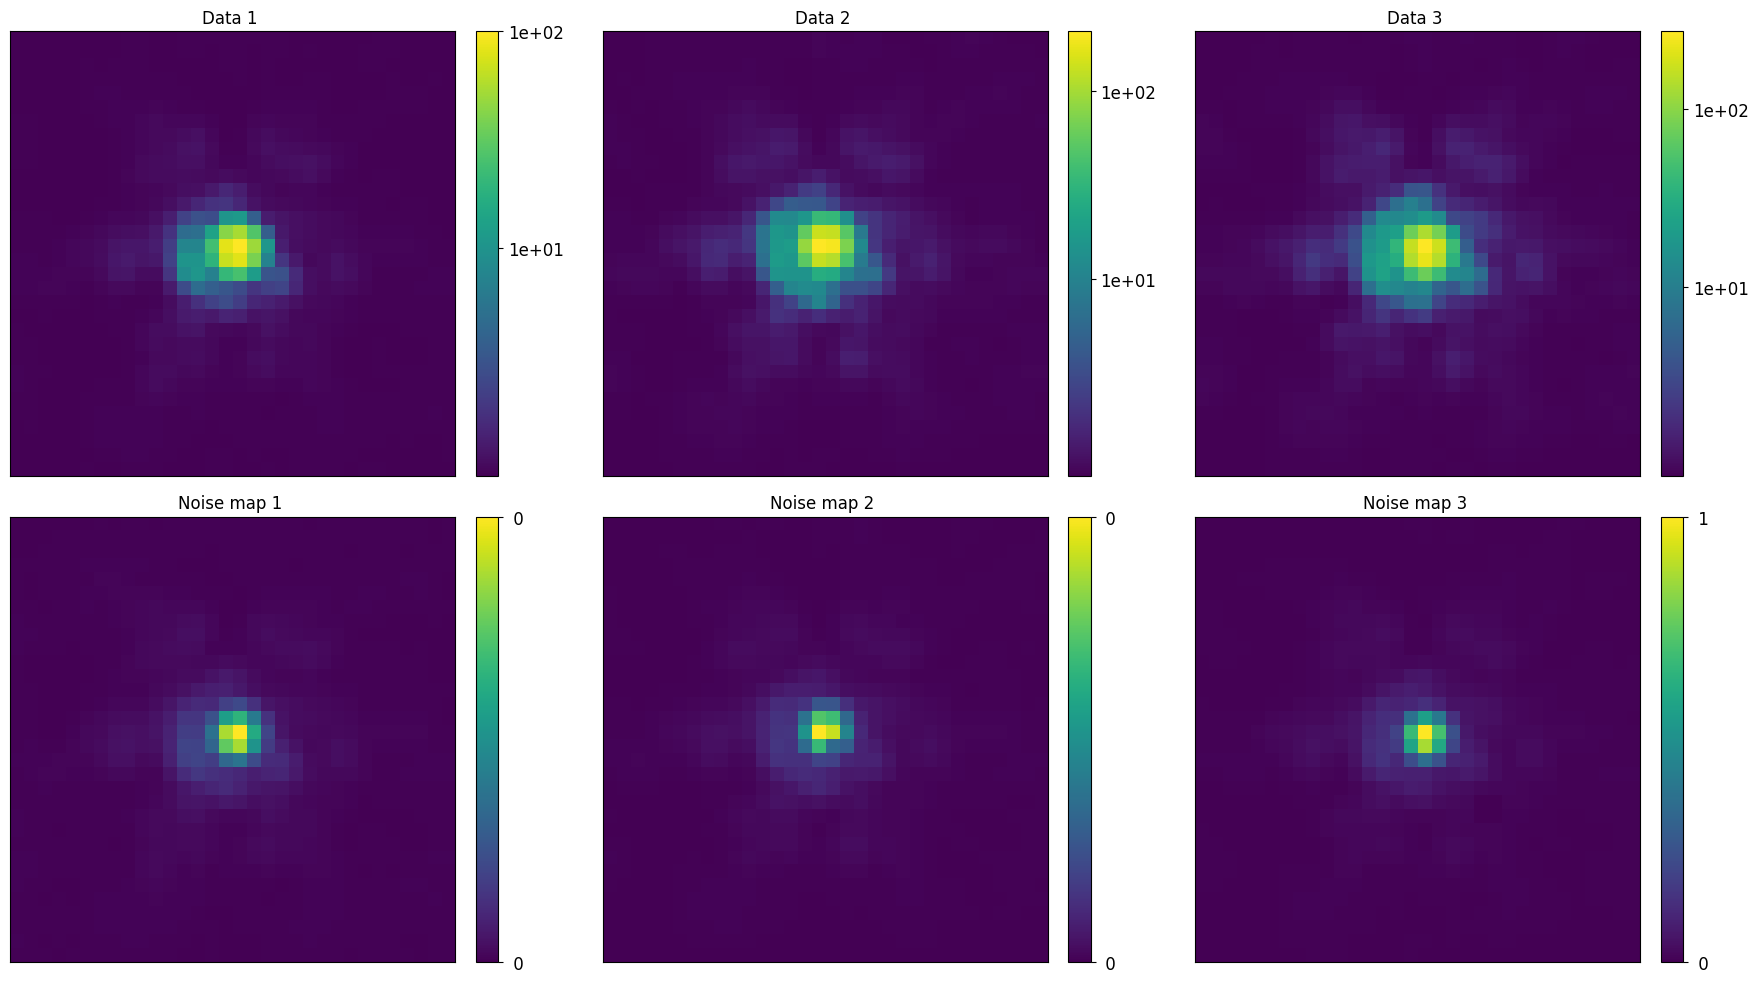

In [9]:
print(np.shape(new_vignets_data))
fig = pltf.display_data(new_vignets_data, sigma_2 = sigma_2)

In [10]:
# Build the PSF model class
model = PSF(image_size=image_size, number_of_sources=N, 
            upsampling_factor=subsampling_factor, 
            convolution_method=convolution_method,
            include_moffat = include_moffat)

# Parameter initialization. 
kwargs_init, kwargs_fixed, kwargs_up, kwargs_down = model.smart_guess(new_vignets_data, fixed_background=False)

print('Initial Guess :', kwargs_init) 

parameters = ParametersPSF(kwargs_init, kwargs_fixed, kwargs_up=kwargs_up, kwargs_down=kwargs_down)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


Initial Guess : {'kwargs_moffat': {'fwhm': 3.0, 'beta': 2.0, 'C': 149.123779296875}, 'kwargs_gaussian': {'a': Array([ 95.352394, 162.10457 , 189.91441 ], dtype=float32), 'x0': array([-0.08397102, -0.24713516,  0.19010353]), 'y0': array([0.02102089, 0.30672264, 0.14050484])}, 'kwargs_background': {'background': Array([0., 0., 0., ..., 0., 0., 0.], dtype=float32), 'mean': Array([0., 0., 0.], dtype=float32)}, 'kwargs_distortion': {'dilation_x': array([0., 0.]), 'dilation_y': array([0., 0.]), 'shear': array([0., 0.])}}


In [11]:
# PSF fitting: 
kwargs_lbfgs = {'maxiter':n_iter_initial}
kwargs_optax = {'max_iterations':n_iter, 'progress_bar':True}

model, parameters, loss, kwargs_partial_list, LogL_list, loss_history_list = run_multi_steps_PSF_reconstruction(new_vignets_data, model, parameters, sigma_2, lambda_scales=lambda_scales,
                                                                                                                lambda_hf = lambda_hf, lambda_positivity=lambda_positivity, 
                                                                                                                method_noise = 'MC', optim_list=['l-bfgs-b', 'adabelief'],
                                                                                                                kwargs_optim_list = [kwargs_lbfgs, kwargs_optax]) 

kwargs_final = kwargs_partial_list[-1]

### Step 1, fixing : ['background'] ###


/home/felipe/miniconda3/envs/SFstarred/lib/python3.12/site-packages/starred/utils/noise_utils.py:53: RuntimeWarning: Mean of empty slice
  noise_map = np.nanmean(centered_masked_noise_maps, axis=0)


Step 1/2 took 18 seconds
Kwargs partial at step 1/2 {'kwargs_moffat': {'fwhm': Array([2.], dtype=float32), 'beta': Array([1.1413102], dtype=float32), 'C': Array([149.12376], dtype=float32)}, 'kwargs_gaussian': {'a': Array([ 74.236595, 128.48314 , 148.28926 ], dtype=float32), 'x0': Array([-0.07430747, -0.30493858,  0.14893292], dtype=float32), 'y0': Array([0.09916402, 0.25839454, 0.12996405], dtype=float32)}, 'kwargs_background': {'background': Array([0., 0., 0., ..., 0., 0., 0.], dtype=float32), 'mean': Array([0., 0., 0.], dtype=float32)}, 'kwargs_distortion': {'dilation_x': Array([0., 0.], dtype=float32), 'dilation_y': Array([0., 0.], dtype=float32), 'shear': Array([0., 0.], dtype=float32)}}
LogL :  1.701915e+06
Overall Reduced Chi2 :  1108.0176
### Step 2, fixing : ['moffat'] ###


optax.adabelief: 100%|██████████| 2000/2000 [00:22<00:00, 87.26it/s] 


Step 2/2 took 23 seconds
Kwargs partial at step 2/2 {'kwargs_moffat': {'fwhm': Array([2.], dtype=float32), 'beta': Array([1.1413102], dtype=float32), 'C': Array([149.12376], dtype=float32)}, 'kwargs_gaussian': {'a': Array([115.87125, 199.47018, 224.99986], dtype=float32), 'x0': Array([ 0.22459882, -0.06326412,  0.5199772 ], dtype=float32), 'y0': Array([0.22442906, 0.5047692 , 0.17770992], dtype=float32)}, 'kwargs_background': {'background': Array([1.7970408 , 0.31231198, 0.2727591 , ..., 0.14544168, 0.17550683,
       0.16606553], dtype=float32), 'mean': Array([0., 0., 0.], dtype=float32)}, 'kwargs_distortion': {'dilation_x': Array([0., 0.], dtype=float32), 'dilation_y': Array([0., 0.], dtype=float32), 'shear': Array([0., 0.], dtype=float32)}}
LogL :  163599.0
Overall Reduced Chi2 :  86.89675


Moffat fit :


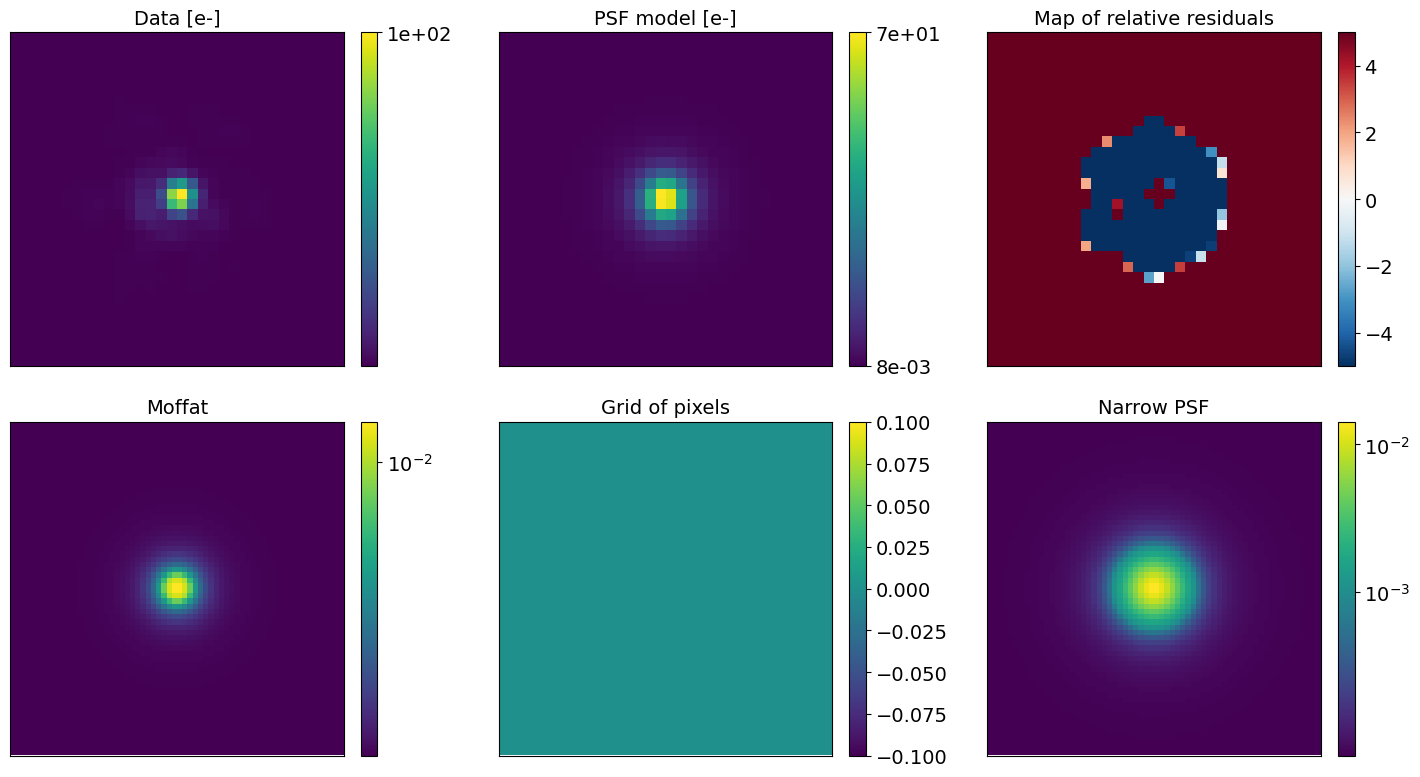

Moffat+ Background fit :


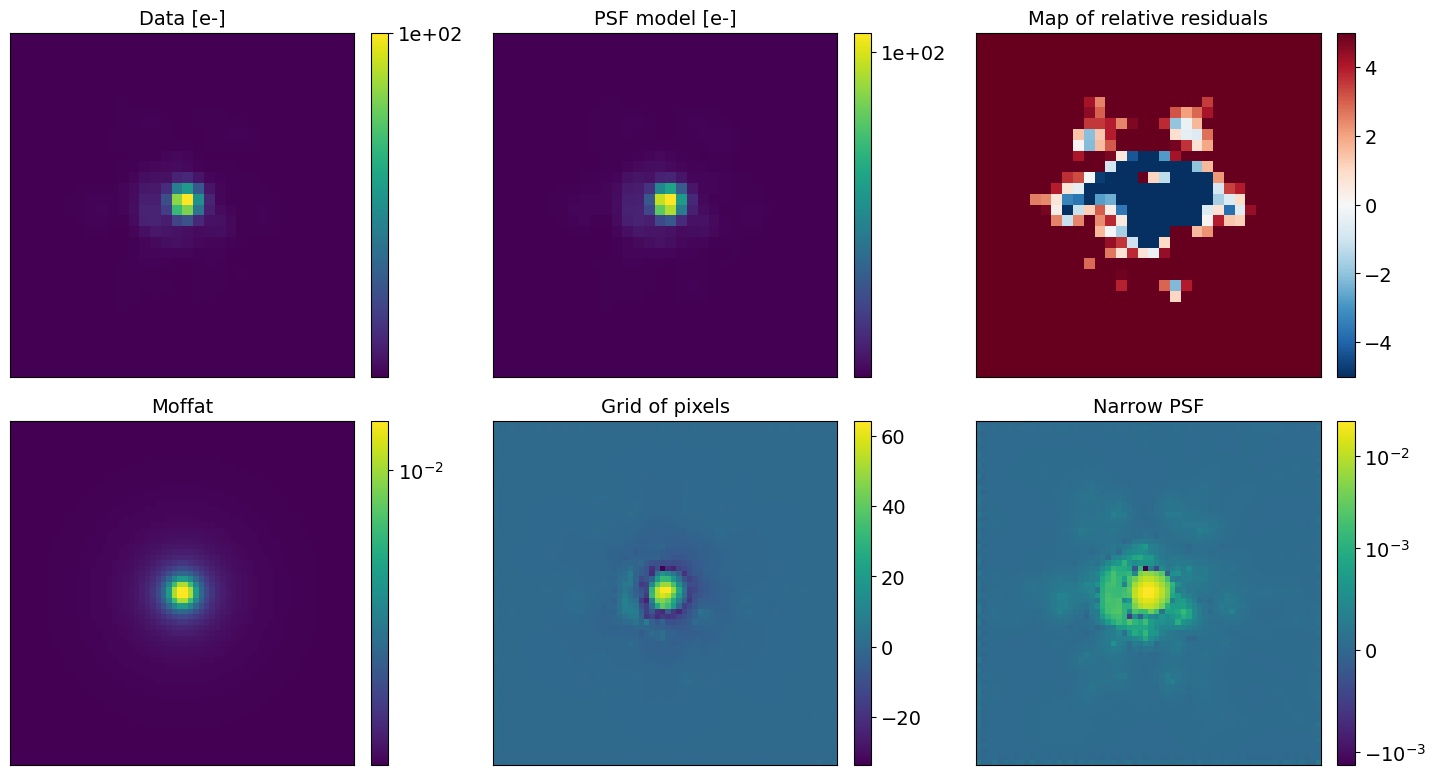

Multiple stars PSF model :


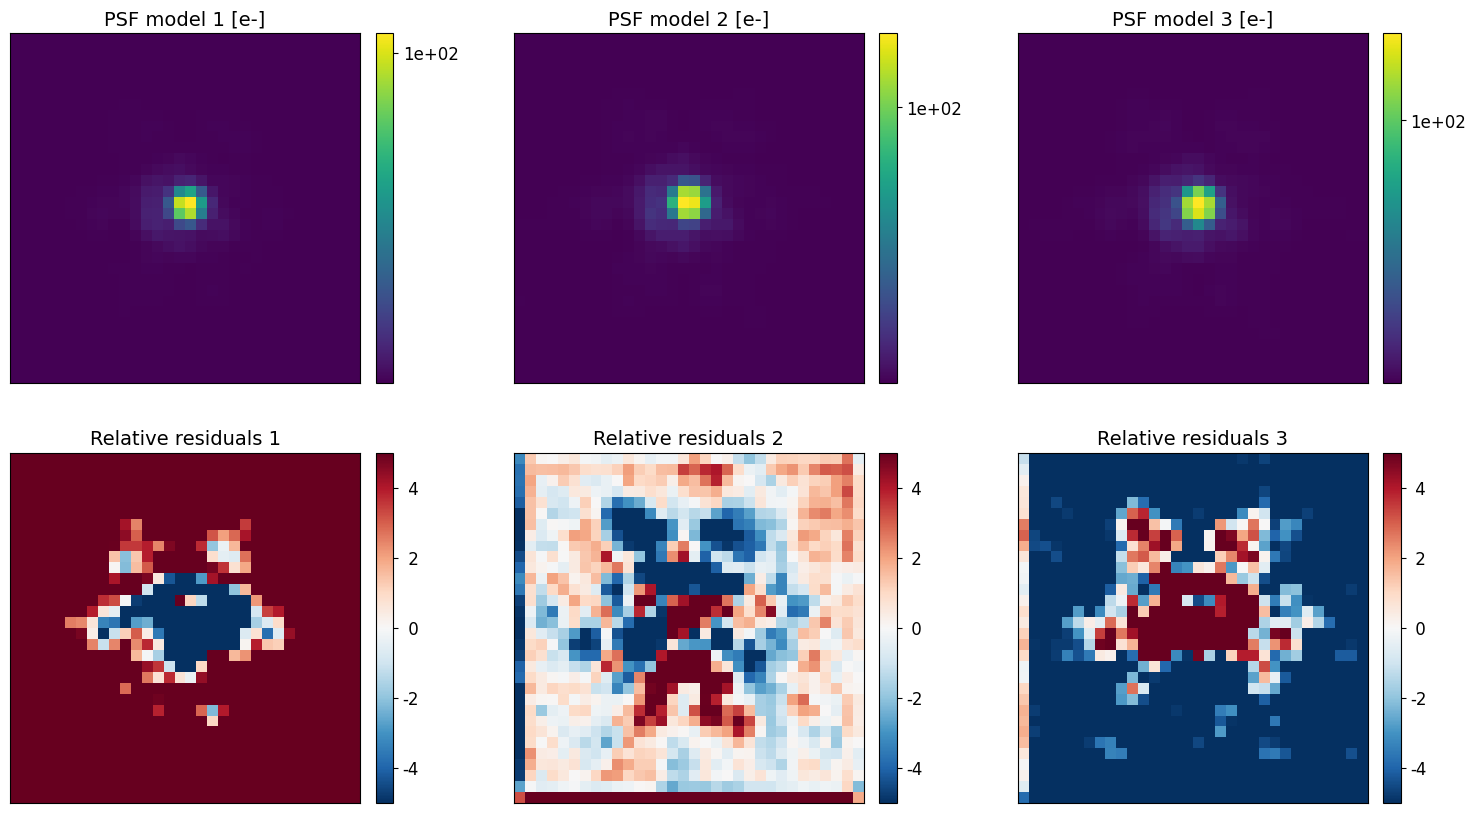

Loss history :


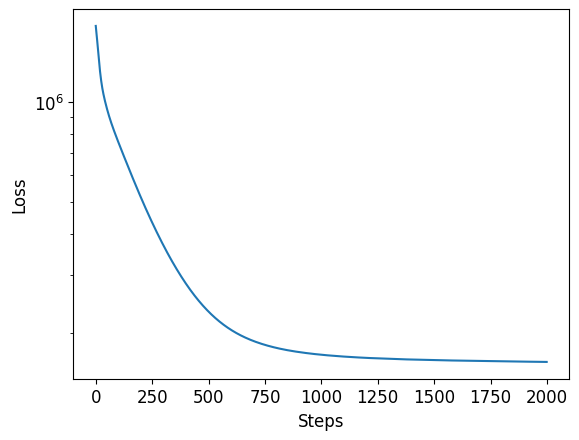

In [12]:
fig1 = pltf.single_PSF_plot(model, new_vignets_data, sigma_2, kwargs_partial_list[0], n_psf=0, units='e-')
print('Moffat fit :')
plt.show(fig1)
fig2 = pltf.single_PSF_plot(model, new_vignets_data, sigma_2, kwargs_final, n_psf=0, units='e-')
print('Moffat+ Background fit :')
plt.show(fig2)
fig3 = pltf.multiple_PSF_plot(model,new_vignets_data, sigma_2, kwargs_final, units='e-')
print('Multiple stars PSF model :')
plt.show(fig3)

fig, ax = plt.subplots(1,1)
ax.plot(range(len(loss_history_list[-1])), loss_history_list[-1])
ax.set_xlabel('Steps')
ax.set_ylabel('Loss')
ax.set_yscale('log')
print('Loss history :')
plt.show(fig)

In [13]:
# Example on how to retrieve different elements of the PSF 
n_psf = 0
estimated_full_psf = model.model(**kwargs_final)[n_psf]
estimated_full_psf_hf = model.model(**kwargs_final, high_res=True)[n_psf]
analytic = model.get_moffat(kwargs_final['kwargs_moffat'], norm=True)
s = model.get_narrow_psf(**kwargs_final, norm=True)
background = model.get_background(kwargs_final['kwargs_background'])

dif = new_vignets_data[n_psf,:,:] - estimated_full_psf
rr = np.abs(dif) / np.sqrt(sigma_2[n_psf,:,:])

# STEP 2 : image deconvolution

From the reconstructed narrow PSF, we now deconvolve the image. 

In [15]:
# Parameters
epochs = 1 #number of epochs
n_iter = 1000
M = 0 #number of point source
method_deconv = 'adabelief'
lambda_scales = 1
lambda_hf = 1000
data_path = 'data/4_galaxy_observation'
noise_map_path = 'data/4_galaxy_noise_map'

In [16]:
# Retrieving data
file_paths = sorted(glob.glob(os.path.join(data_path, '*f200w*.npy')))
data = np.array([np.load(f) for f in file_paths])/1.

im_size = np.shape(data)[1]
im_size_up = im_size * subsampling_factor

print('Data shape:', data.shape)

# PSF reshaping
s = s.reshape(epochs, s.shape[-1], s.shape[-1])
print('Narrow PSF shape:', s.shape)

# Noise map 
sigma_paths = sorted(glob.glob(os.path.join(noise_map_path, '*f200w*.npy')))
sigma_2 = np.array([np.load(f) for f in sigma_paths]) ** 2



Data shape: (1, 80, 80)
Narrow PSF shape: (1, 64, 64)


In [36]:
def plot_image_and_noisemap(
    data,
    noisemaps,
    image_positions,
    image_names=None,
    figsize=(12, 5),
    cmap_data="gray",
    cmap_noise="viridis",
    marker="x",
    marker_color="red",
    marker_size=80,
    text_color="white",
    vmin=None,
    vmax=None,
    noise_vmin=None,
    noise_vmax=None,
):
    """
    Plot the science image and the noise map side by side.

    Parameters
    ----------
    data : array-like
        2D science image.
    noisemaps : array-like
        2D noise map or variance map.
    image_positions : array-like
        Pixel positions of the lensed images. Expected shape is (N, 2),
        where columns are x and y pixel coordinates.
    image_names : list of str, optional
        Names/labels of the images, e.g. ["A", "B", "C", "D"].
    figsize : tuple, optional
        Figure size.
    cmap_data : str, optional
        Colormap for the science image.
    cmap_noise : str, optional
        Colormap for the noise map.
    marker : str, optional
        Marker style for image positions.
    marker_color : str, optional
        Marker color.
    marker_size : float, optional
        Marker size.
    text_color : str, optional
        Color of the image labels.
    vmin, vmax : float, optional
        Intensity limits for the science image.
    noise_vmin, noise_vmax : float, optional
        Intensity limits for the noise map.

    Returns
    -------
    fig : matplotlib.figure.Figure
        Figure object.
    ax : numpy.ndarray
        Array of axes.
    """

    data = np.asarray(data)
    noisemaps = np.asarray(noisemaps)
    #image_positions = np.asarray(image_positions)

    if data.ndim != 2:
        raise ValueError(f"`data` must be 2D, but got shape {data.shape}")

    if noisemaps.ndim != 2:
        raise ValueError(f"`noisemaps` must be 2D, but got shape {noisemaps.shape}")

    if data.shape != noisemaps.shape:
        raise ValueError(
            f"`data` and `noisemaps` must have the same shape, "
            f"but got {data.shape} and {noisemaps.shape}"
        )

    fig, ax = plt.subplots(1, 2, figsize=figsize, constrained_layout=True)

    im0 = ax[0].imshow(
        data,
        origin="lower",
        cmap=cmap_data,
        vmin=vmin,
        vmax=vmax,
    )

    ax[0].set_title("Image")
    ax[0].set_xlabel("x [pix]")
    ax[0].set_ylabel("y [pix]")

    cbar0 = fig.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)
    cbar0.set_label("Flux")

    im1 = ax[1].imshow(
        noisemaps,
        origin="lower",
        cmap=cmap_noise,
        vmin=noise_vmin,
        vmax=noise_vmax,
    )

    ax[1].set_title("Noise map")
    ax[1].set_xlabel("x [pix]")
    ax[1].set_ylabel("y [pix]")

    cbar1 = fig.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)
    cbar1.set_label("Noise")

    return fig, ax

(array([  16.,    3.,   13.,   86.,  415.,  771., 1012., 1786., 2100.,
         198.]),
 array([0.12641867, 0.49450958, 0.86260051, 1.23069155, 1.59878242,
        1.96687329, 2.33496428, 2.70305514, 3.07114601, 3.43923688,
        3.80732799]),
 <BarContainer object of 10 artists>)

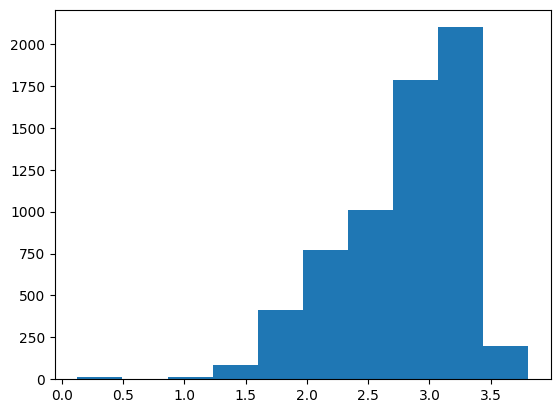

In [41]:
plt.hist((np.sqrt(sigma_2[0])/data[0]).ravel()*100)

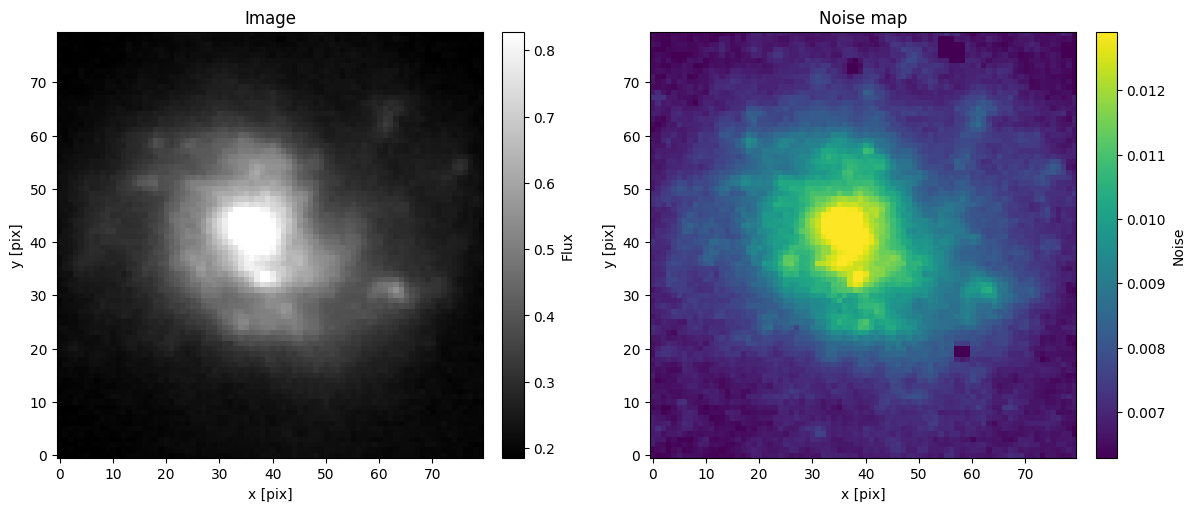

In [43]:
fig, ax = plot_image_and_noisemap(
    data=data[0],
    noisemaps=np.sqrt(sigma_2[0]),
    image_positions=None,
    image_names=None,
    vmin=np.nanpercentile(data[0], 1),
    vmax=np.nanpercentile(data[0], 99),
    noise_vmin=np.nanpercentile(np.sqrt(sigma_2[0]), 1),
    noise_vmax=np.nanpercentile(np.sqrt(sigma_2[0]), 99),
)

In [30]:
data.shape

(1, 80, 80)

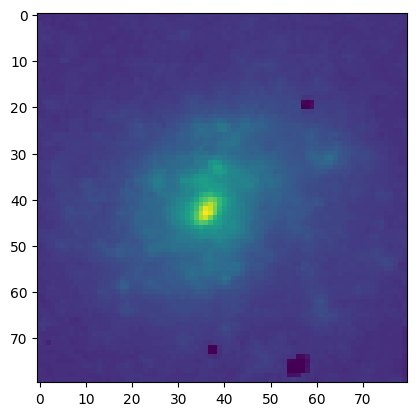

In [ ]:
plt.imshow(sigma_2[0])


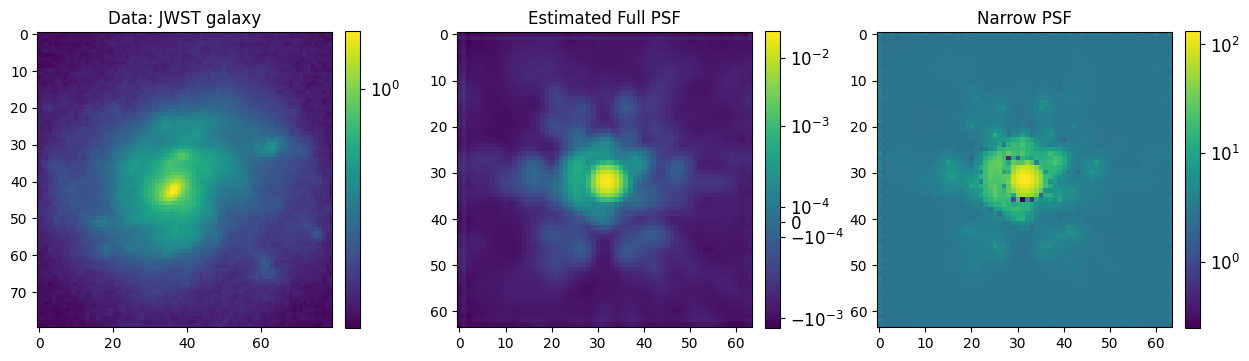

In [18]:
fig, axs = plt.subplots(1, 3, figsize=(15,15))
plt.subplots_adjust(wspace=0.3)
fraction = 0.046
pad = 0.04

plt.rc('font', size=12)           
axs[0].set_title('Data: JWST galaxy', fontsize=12)
axs[0].tick_params(axis='both', which='major', labelsize=10)
axs[2].set_title('Narrow PSF', fontsize=12)
axs[2].tick_params(axis='both', which='major', labelsize=10)
axs[1].set_title('Estimated Full PSF', fontsize=12)
axs[1].tick_params(axis='both', which='major', labelsize=10)

fig.colorbar(axs[0].imshow(data[0,:,:], norm=colors.SymLogNorm(linthresh=5e-4)), ax=axs[0], fraction=fraction, pad=pad)
fig.colorbar(axs[2].imshow(s[0,:,:], norm=colors.SymLogNorm(linthresh=5e-4)), ax=axs[1], fraction=fraction, pad=pad)
fig.colorbar(axs[1].imshow(estimated_full_psf_hf, norm=colors.SymLogNorm(linthresh=5e-4)), ax=axs[2], fraction=fraction, pad=pad)
plt.show()

In [19]:
# Parameter initialization
initial_c_x = np.array([]) 
initial_c_y = np.array([]) 

model, kwargs_init, kwargs_up, kwargs_down, kwargs_fixed = setup_model(data, 
                                                                       sigma_2, 
                                                                       s, 
                                                                       initial_c_x,
                                                                       initial_c_y, 
                                                                       subsampling_factor)

parameters = ParametersDeconv(kwargs_init, 
                              kwargs_fixed, 
                              kwargs_up=kwargs_up, 
                              kwargs_down=kwargs_down)


/home/felipe/miniconda3/envs/SFstarred/lib/python3.12/site-packages/starred/deconvolution/deconvolution.py:75: UserWarning: The narrow PSF does not have the same size as the upsampled image. This might be desired to speed up the computation but make sure it is at the resolution of the upsampled image.
  warnings.warn(


In [20]:
# compute noise level in starlet space
W = propagate_noise(model, np.sqrt(sigma_2), kwargs_init, wavelet_type_list=['starlet'], 
                    method='MC', num_samples=500, seed=1, likelihood_type='chi2', 
                    verbose=False, upsampling_factor=subsampling_factor)[0]

loss = decLoss(data, model, parameters, sigma_2, 
               regularization_terms='l1_starlet', 
               regularization_strength_scales=lambda_scales, 
               regularization_strength_hf=lambda_hf, W=W) 


In [21]:
optim = Optimizer(loss, parameters, method=method_deconv )
best_fit, logL_best_fit, extra_fields, runtime = optim.minimize(max_iterations=n_iter, restart_from_init=True, init_learning_rate=1e-3) 

optax.adabelief: 100%|██████████| 1000/1000 [00:56<00:00, 17.55it/s]


{'kwargs_analytic': {'a': Array([], shape=(0,), dtype=float32), 'c_x': Array([], shape=(0,), dtype=float32), 'c_y': Array([], shape=(0,), dtype=float32), 'dx': Array([0.], dtype=float32), 'dy': Array([0.], dtype=float32), 'alpha': Array([0.], dtype=float32)}, 'kwargs_background': {'mean': Array([0.0397161], dtype=float32), 'h': Array([-0.02779271, -0.01824083, -0.01195224, ..., -0.01087894,
       -0.01704706, -0.0274313 ], dtype=float32)}, 'kwargs_sersic': {'amp': Array([], shape=(0,), dtype=float32), 'R_sersic': Array([], shape=(0,), dtype=float32), 'n_sersic': Array([], shape=(0,), dtype=float32), 'center_x': Array([], shape=(0,), dtype=float32), 'center_y': Array([], shape=(0,), dtype=float32), 'e1': Array([], shape=(0,), dtype=float32), 'e2': Array([], shape=(0,), dtype=float32)}}


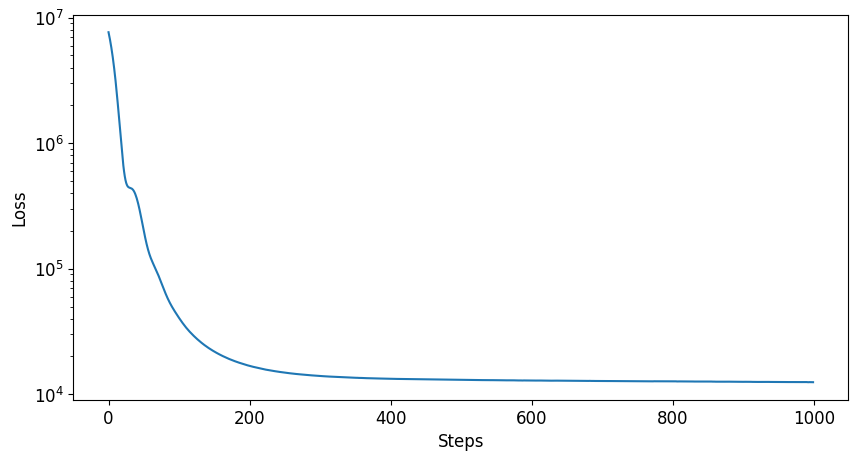

In [22]:
# Printing final results
kwargs_final = deepcopy(parameters.best_fit_values(as_kwargs=True))
print(kwargs_final)
fig = pltf.plot_loss(extra_fields['loss_history'])



In [23]:
# Retrieving different elements of the deconvolved image
epoch = 0
output = model.model(kwargs_final)[epoch]
deconv, h = model.getDeconvolved(kwargs_final, epoch)

data_show = data[epoch,:,:] 

dif = data_show - output
rr = np.abs(dif) / np.sqrt(sigma_2[epoch,:,:])

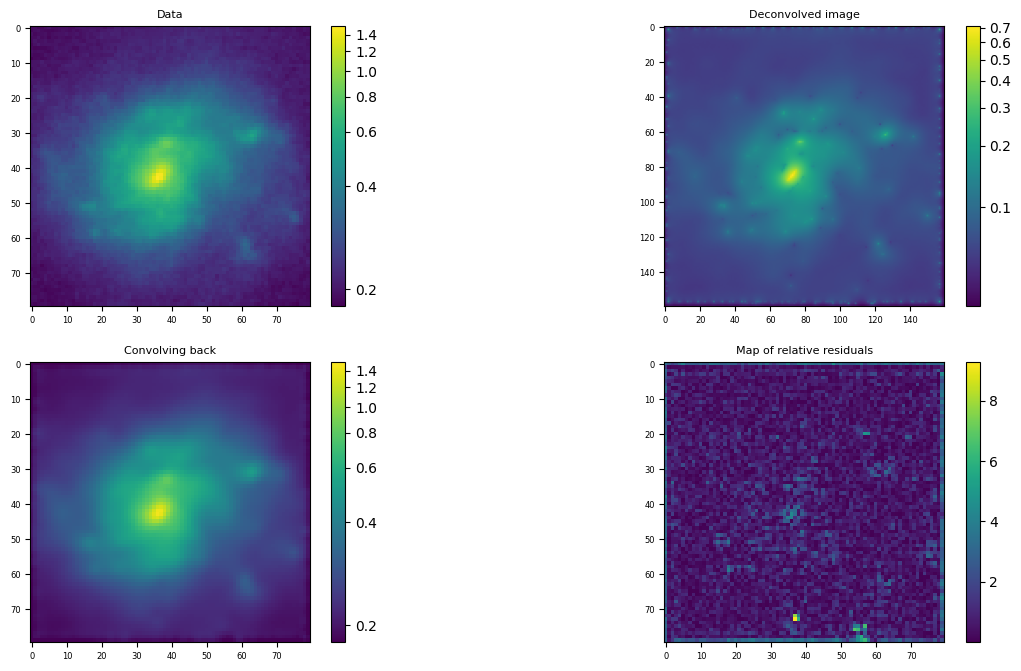

In [24]:
fig, axs = plt.subplots(2, 2, figsize=(15,8))
fraction = 0.046
pad = 0.04
font_size = 10
ticks_size = 6

from astropy.visualization import (imshow_norm, MinMaxInterval,
                                   SqrtStretch, AsinhStretch)
stretch = AsinhStretch

plt.rc('font', size=font_size)           
axs[0,0].set_title('Data', fontsize=8)
axs[0,0].tick_params(axis='both', which='major', labelsize=ticks_size)

axs[0,1].set_title('Deconvolved image', fontsize=8)
axs[0,1].tick_params(axis='both', which='major', labelsize=ticks_size)

axs[1,0].set_title('Convolving back', fontsize=8)
axs[1,0].tick_params(axis='both', which='major', labelsize=ticks_size)

axs[1,1].set_title('Map of relative residuals', fontsize=8)
axs[1,1].tick_params(axis='both', which='major', labelsize=ticks_size)


im, norm = imshow_norm(data_show, axs[0,0], interval=MinMaxInterval(), stretch=stretch())
fig.colorbar(im, ax=axs[0,0], fraction=fraction, pad=pad)
im2, _ = imshow_norm(h, axs[0,1], interval=MinMaxInterval(), stretch=stretch())
fig.colorbar(im2, ax=axs[0,1], fraction=fraction, pad=pad)
fig.colorbar(axs[1,0].imshow(output, norm=norm), ax=axs[1,0], fraction=fraction, pad=pad)
fig.colorbar(axs[1,1].imshow(rr), ax=axs[1,1], fraction=fraction, pad=pad) 
plt.show()

In [20]:
input_flux = data.sum()
output_flux = output.sum()

print('Data flux: ' + str(input_flux))
print('Deconvolved image flux: ' + str(output_flux))
print('Flux change: ' + str(100 * abs(input_flux-output_flux) / input_flux) + '%')

print('Overall Reduced Chi2 : ', loss.reduced_chi2(kwargs_final))

Data flux: 1947.2152
Deconvolved image flux: 1943.771185126359
Flux change: 0.1768692447019096%
Overall Reduced Chi2 :  1.232188783170871


In [21]:
#save results 
#from starred.utils.generic_utils import save_fits

#output_path = Path('./output/JWST')
#output_path.mkdir(parents=1, exist_ok=1)
#model.export(output_path, kwargs_final, data, sigma_2, format='fits')